# <div align="center"><u>The high spearman's rank correlation dataset</u>

## - General description of the spearman's rank dataset:
    
The following implementation applies a high spearman's rank correlation filter to the Colon-Kidney dataset, where the dimensionality ranges between 55 and 110 features (gene expressions).

##############################################################################################################################

###  Import some useful libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import random
from sklearn import metrics

import time

### Suppress warnings

In [2]:
# import warnings

# # To suppress all warnings
# warnings.filterwarnings("ignore")

### Start time

In [3]:
# Start time
start_time = time.time()

### Load the final colon-kidney dataset and store it within a pandas DataFrame

In [4]:
# Load the dataset and store it within a pandas dataframe to handle it easier
df = pd.read_csv(r"C:\Users\user\Desktop\AUTH\Διπλωματική\Python\The colon-kidney final dataset.csv")

# Print the dataset
df

,1007_s_at,121_at,1405_i_at,1438_at,1487_at,1494_f_at,1552256_a_at,1552257_a_at,1552274_at,1552275_s_at,...,AFFX-r2-Ec-bioC-5_at,AFFX-r2-Ec-bioD-3_at,AFFX-r2-Ec-bioD-5_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,Target,Tissue
0,2883.2,2109.1,702.0,114.4,822.2,235.1,3346.1,815.1,233.3,218.4,...,1908.1,30396.7,28371.7,85830.1,57084.9,3651.2,1736.1,2411.6,0,Kidney
1,2607.4,1204.2,228.0,19.2,1497.1,167.6,23003.6,948.6,414.1,124.1,...,3012.0,16748.8,13581.2,53322.5,37139.5,1648.1,502.9,890.6,0,Kidney
2,2736.8,3912.2,1020.8,39.0,574.9,448.9,1337.9,605.6,176.8,411.9,...,14835.5,64597.8,59311.2,203060.6,146422.6,3346.4,673.2,1499.3,0,Kidney
3,1471.6,1318.2,4564.6,9.4,1426.5,105.2,2594.3,929.8,240.4,139.0,...,11300.8,58551.7,49073.6,119460.8,95682.3,2553.5,961.2,1468.4,0,Kidney
4,3564.7,2535.6,944.1,40.0,734.2,651.0,1490.5,712.3,632.7,185.0,...,12966.9,54572.5,51049.1,178178.2,129533.2,3399.1,1209.8,1981.6,0,Kidney
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541,3197.8,713.4,191.1,747.0,1597.8,179.5,1717.2,2261.2,305.5,181.8,...,1494.9,22165.4,20442.0,65246.8,46710.2,2057.3,810.0,1338.2,1,Colon
542,2161.9,1244.3,2347.0,1995.6,697.8,194.6,508.4,1042.5,729.7,537.2,...,4588.2,21225.6,20067.2,80607.7,60204.9,1116.3,432.8,744.5,1,Colon
543,4105.2,664.4,445.2,7008.2,1887.0,204.0,1951.8,2540.1,259.2,239.5,...,1318.0,19659.4,15774.8,56065.6,43347.8,1191.2,371.3,688.5,1,Colon
544,4204.7,894.2,102.8,1374.8,2891.5,306.2,1397.9,2072.4,474.0,316.3,...,6375.2,34393.5,29137.7,89215.2,71290.1,1878.7,1009.7,1126.6,1,Colon


### Compute the spearman's rank correlation between each pair of features

In [5]:
# Compute the spearman's rank correlation matrix of the features
correlation_matrix = df.iloc[:, :-2].corr(method='spearman') #Exclude last 2 columns ('Target' and 'Tissue')

### Get the absolute values of spearman's rank correlation (as unique values) in order to plot them

In [6]:
# Assuming correlation_matrix is a square DataFrame of Pearson correlations

# Get the upper triangle of the correlation matrix without the diagonal
upper_tri = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))

# Flatten and drop NaNs to get all correlation pairs (no sorting)
correlations = upper_tri.stack().abs()  # absolute values of correlation

In [7]:
print("Total number of correlation pairs:", len(correlations.values))
print("Maximum correlation value (absolute):", max(correlations.values))
print("Minimum correlation value (absolute):", min(correlations.values))
print("Average (mean) correlation value (absolute):", np.mean(correlations.values))

Total number of correlation pairs: 59781645
Maximum correlation value (absolute): 0.9987747187317823
Minimum correlation value (absolute): 0.0
Average (mean) correlation value (absolute): 0.21025722757728596


### Plot the spearman's rank correlation between some features in a bar plot in order to visualize them
- We do not plot all of the spearman's rank correlation values since they are so many (almost 60 millions) and it takes such a very long period of time to do so.

### Limit to the first 10K spearman's rank correlation values to plot (due to computational cost reasons)

In [8]:
# Limit to the first 10,000 correlation values
correlations_subset = correlations[:10000]

### Plot the first 10K spearman's rank correlation values 

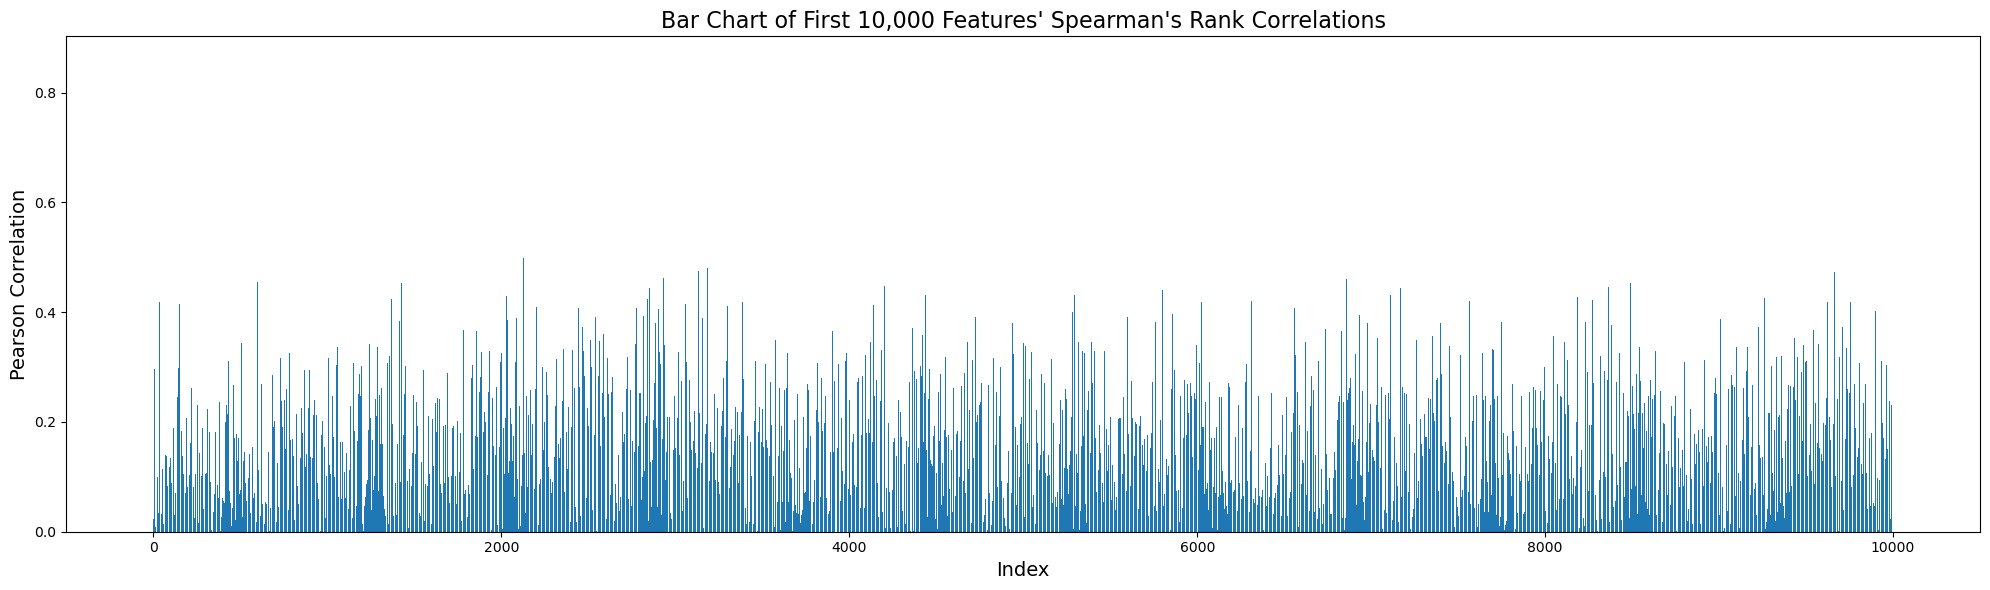

In [9]:
# Create a figure for the bar chart
plt.figure(figsize=(20, 6))

# Create the bar chart
plt.bar(range(len(correlations_subset)), correlations_subset.values)

# Set labels and title
plt.xlabel("Index", fontsize=14)
plt.ylabel("Pearson Correlation", fontsize=14)
plt.title("Bar Chart of First 10,000 Features' Spearman's Rank Correlations", fontsize=16)

# Tight layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()

### Apply the spearman's rank correlation filter

In [10]:
#Function that creates and returns a new dataframe based on an old one and correlation threshold

def returnNewDataframe(df, correlation_matrix, correlation_threshold):
    # Identify highly correlated features: Create a mask to identify which features have correlation 
    # above the threshold and less than 1.00
    high_corr_mask = (correlation_matrix.abs() > correlation_threshold) & (correlation_matrix.abs() < 1.00).any()

    # Create a Set of Features to Remove
    features_to_drop = set()
    for feature in high_corr_mask.columns:
        correlated_features = high_corr_mask.index[high_corr_mask[feature]].tolist()
        for correlated_feature in correlated_features:
            if correlated_feature != feature:
                features_to_drop.add(correlated_feature)

    # Remove redundant features and return the dataframe
    return df.drop(columns=features_to_drop)

### Set spearman's rank correlation threshold (target -> 55 - 110 features)

In [11]:
# Set a threshold for correlation filter
correlation_threshold = 0.35  # Adjust this threshold as needed

### Create the new dataframe based on the spearman's rank correlation filter's threshold

In [12]:
df_new = returnNewDataframe(df, correlation_matrix, correlation_threshold)

# Rename the new DataFrame
df = df_new

df

,1555989_at,1561817_at,1569532_a_at,200697_at,201397_at,201542_at,202965_s_at,202991_at,203673_at,203815_at,...,232252_at,235333_at,235737_at,235763_at,238717_at,239990_at,240717_at,243938_x_at,Target,Tissue
0,996.5,85.3,34.6,1619.5,688.8,2742.9,58.7,215.0,125.3,2125.3,...,98.9,491.5,55.4,82.4,513.4,46.1,8.1,93.8,0,Kidney
1,256.4,30.1,37.8,1874.4,195.4,2549.5,3.6,342.9,135.2,1953.9,...,54.6,151.4,8.7,14.4,228.3,43.0,36.0,108.8,0,Kidney
2,458.8,20.1,260.9,1934.8,466.1,3294.8,62.0,215.1,343.4,1184.9,...,230.5,1284.8,19.0,17.7,2462.5,55.3,62.7,111.4,0,Kidney
3,892.1,102.7,52.8,1935.2,571.0,2498.4,26.5,337.8,158.4,921.9,...,74.5,309.6,74.2,47.5,50.6,15.7,64.3,7.0,0,Kidney
4,830.2,105.6,66.9,2082.8,373.2,3128.0,266.9,265.2,245.6,26.7,...,200.3,475.0,18.8,660.7,711.8,67.2,46.2,127.4,0,Kidney
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541,265.6,40.2,15.6,1377.3,799.6,2002.5,28.6,720.3,253.0,479.4,...,1764.3,633.4,11.3,22.1,69.6,15.9,14.9,7.3,1,Colon
542,368.6,388.6,92.3,2093.9,884.1,3110.0,423.9,258.5,150.9,340.5,...,50.3,492.6,27.1,270.8,471.6,29.8,37.1,101.9,1,Colon
543,459.2,41.0,5955.6,1392.9,463.7,2510.7,362.1,716.6,111.9,1059.5,...,135.4,487.5,122.3,40.8,54.5,89.8,7.6,81.6,1,Colon
544,457.7,48.7,85.6,1396.1,586.8,2650.6,16.0,381.7,290.8,830.1,...,434.2,664.4,131.3,373.3,124.3,16.0,68.4,9.6,1,Colon


### Export the spearman's rank filtered dataset to .csv file

In [13]:
# Export to .csv file
file_path = r"C:\Users\user\Desktop\AUTH\Διπλωματική\Python\Dimensionality Reduction Methods\High Correlation Filters\Spearman's Rank Correlation\The colon-kidney high spearman's rank correlation filtered dataset.csv"
df.to_csv(file_path, index=False)

print(f"CSV file saved at: {file_path}")

CSV file saved at: C:\Users\user\Desktop\AUTH\Διπλωματική\Python\Dimensionality Reduction Methods\High Correlation Filters\Spearman's Rank Correlation\The colon-kidney high spearman's rank correlation filtered dataset.csv


### Transform outliers

In [14]:
# Function that tranforms outliers given a dataframe
def cap_outliers_iqr(df, threshold=1.5):
    df_capped = df.copy()
    for col in df.columns:
        if col in df_capped.columns and pd.api.types.is_numeric_dtype(df_capped[col]):
            Q1 = df_capped[col].quantile(0.25)
            Q3 = df_capped[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - threshold * IQR
            upper_bound = Q3 + threshold * IQR

            df_capped[col] = np.where(df_capped[col] < lower_bound, lower_bound, df_capped[col])
            df_capped[col] = np.where(df_capped[col] > upper_bound, upper_bound, df_capped[col])
        else:
            print(f"Warning: Column '{col}' not found or is not numeric. Skipping.")
    return df_capped

In [15]:
# Transform outliers
df_capped = cap_outliers_iqr(df)
df_capped

,1555989_at,1561817_at,1569532_a_at,200697_at,201397_at,201542_at,202965_s_at,202991_at,203673_at,203815_at,...,232252_at,235333_at,235737_at,235763_at,238717_at,239990_at,240717_at,243938_x_at,Target,Tissue
0,996.5,85.300,34.600,1619.5,688.8,2742.9,58.7,215.000,125.3,2125.3,...,98.9000,491.5000,55.4,82.4,513.400,46.1,8.1,93.8,0.0,Kidney
1,256.4,30.100,37.800,1874.4,195.4,2549.5,3.6,342.900,135.2,1953.9,...,54.6000,151.4000,8.7,14.4,228.300,43.0,36.0,108.8,0.0,Kidney
2,458.8,20.100,260.900,1934.8,466.1,3294.8,62.0,215.100,343.4,1184.9,...,230.5000,1239.1125,19.0,17.7,1216.725,55.3,62.7,111.4,0.0,Kidney
3,892.1,102.700,52.800,1935.2,571.0,2498.4,26.5,337.800,158.4,921.9,...,74.5000,309.6000,74.2,47.5,50.600,15.7,64.3,7.0,0.0,Kidney
4,830.2,105.600,66.900,2082.8,373.2,3128.0,266.9,265.200,245.6,26.7,...,200.3000,475.0000,18.8,660.7,711.800,67.2,46.2,127.4,0.0,Kidney
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541,265.6,40.200,15.600,1377.3,799.6,2002.5,28.6,599.625,253.0,479.4,...,477.6625,633.4000,11.3,22.1,69.600,15.9,14.9,7.3,1.0,Colon
542,368.6,219.075,92.300,2093.9,884.1,3110.0,423.9,258.500,150.9,340.5,...,50.3000,492.6000,27.1,270.8,471.600,29.8,37.1,101.9,1.0,Colon
543,459.2,41.000,321.575,1392.9,463.7,2510.7,362.1,599.625,111.9,1059.5,...,135.4000,487.5000,122.3,40.8,54.500,89.8,7.6,81.6,1.0,Colon
544,457.7,48.700,85.600,1396.1,586.8,2650.6,16.0,381.700,290.8,830.1,...,434.2000,664.4000,131.3,373.3,124.300,16.0,68.4,9.6,1.0,Colon


### Check if "Transform Outliers" worked: Count how many elements are different between dataframes. If 0 nothing happened

In [16]:
# Compare element-wise and count differences
num_differences = (df != df_capped).sum().sum()

# Print results
if num_differences > 0:
    print(f"The tranformation of outliers worked. The amount of outliers that has been transformed is: {num_differences}")
else:
    print("No values transformed during outliers transformation phase")

The tranformation of outliers worked. The amount of outliers that has been transformed is: 3160


### Export the dataset to .csv file

In [17]:
# Export to .csv file
file_path = r"C:\Users\user\Desktop\AUTH\Διπλωματική\Python\Dimensionality Reduction Methods\High Correlation Filters\Spearman's Rank Correlation\The colon-kidney high spearman's rank correlation filtered capped dataset.csv"
df_capped.to_csv(file_path, index=False)

print(f"CSV file saved at: {file_path}")

CSV file saved at: C:\Users\user\Desktop\AUTH\Διπλωματική\Python\Dimensionality Reduction Methods\High Correlation Filters\Spearman's Rank Correlation\The colon-kidney high spearman's rank correlation filtered capped dataset.csv


### End time

In [18]:
# End time
end_time = time.time()

### Elapsed time

In [19]:
# Elapsed time
elapsed_time = end_time - start_time

print(f"Elapsed time for High Spearman's Rank Correlation Dataset: {elapsed_time:.2f} seconds")

Elapsed time for High Spearman's Rank Correlation Dataset: 236.31 seconds
